In [70]:
# Credit Card Fraud Detection

## 1. Project Overview
## 2. Import Libraries
## 3. Load Dataset
## 4. Data Understanding
## 5. Data Quality & Duplicate Analysis
## 6. Exploratory Data Analysis
## 7. Feature and Target Definition
## 8. Temporal Train-Validation-Test Split
## 9. Class Imbalance Handling
## 10. Baseline Model - Logistic Regression
## 11. Random Forest Model
## 12. HistGradientBoosting Model
## 13. Model Comparison
## 14. Threshold Optimization
## 15. Error Analysis
## 16. Feature Importance
## 17. Final Model Evaluation
## 18. Model Saving
## 19. Production Inference Test
## 20. Conclusion

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [9]:
print("Shape:", df.shape)

Shape: (284807, 31)


In [10]:
df.size

8829017

In [15]:
print("Shape:", df.shape)
print("\nColumns:")       # rows and columns, & no. of columns
print(df.columns.tolist())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [16]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [17]:
print("\nMissing Values:")
print(df.isnull().sum().sum())



Missing Values:
0


In [18]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
1081


In [19]:
dup = df[df.duplicated(keep=False)]

print("Duplicate rows:", len(dup))

Duplicate rows: 1854


In [22]:
print("\nClass distribution in duplicates:")
print(dup["Class"].value_counts())



Class distribution in duplicates:
Class
0    1822
1      32
Name: count, dtype: int64


In [23]:
print("\nDuplicate groups with conflicting Class:")
print(
    dup.groupby(list(df.columns[:-1]))["Class"]
       .nunique()
       .value_counts()
)


Duplicate groups with conflicting Class:
Class
1    773
Name: count, dtype: int64


In [24]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 284807
Rows after: 283726
Duplicates removed: 1081


In [26]:
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print("Transaction Counts:")
print(class_counts)

print("\nTransaction Percentage:")
print(class_percent)        # if negative : its genuine(0) but if positive  its fraud(1).

Transaction Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Transaction Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


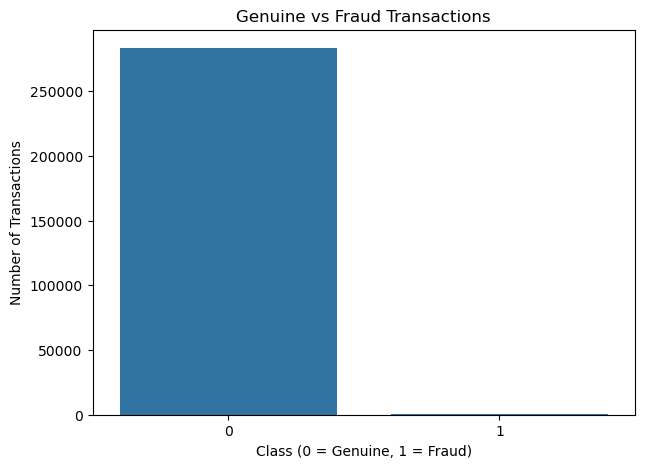

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Genuine vs Fraud Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

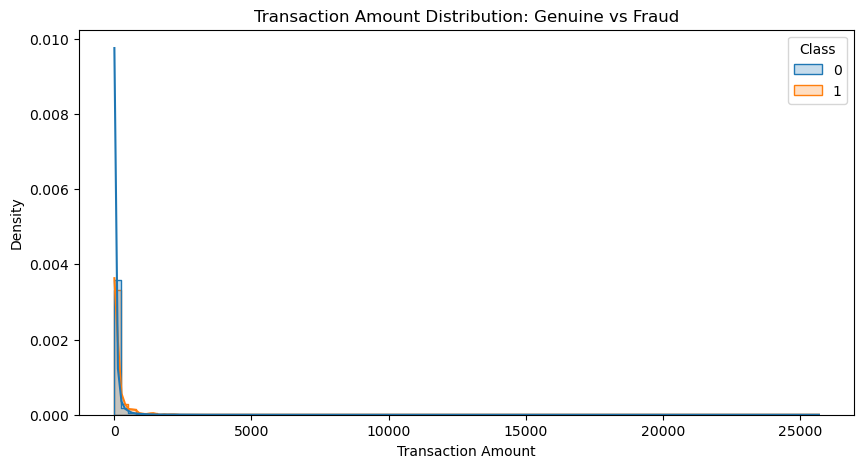

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution: Genuine vs Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()


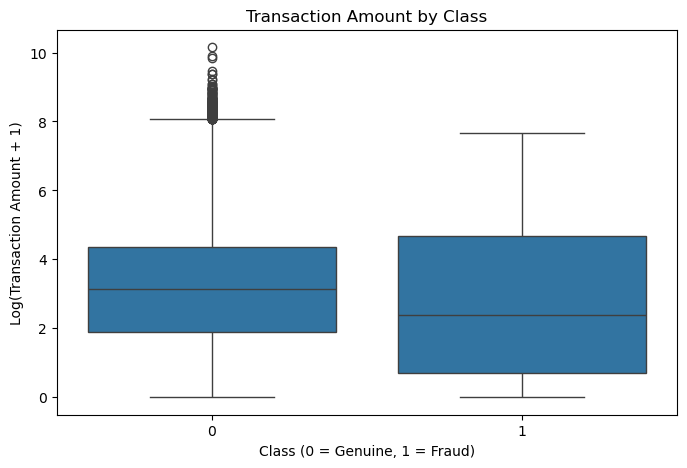

In [30]:
df["Amount_Log"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Class", y="Amount_Log")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount + 1)")
plt.title("Transaction Amount by Class")
plt.show()

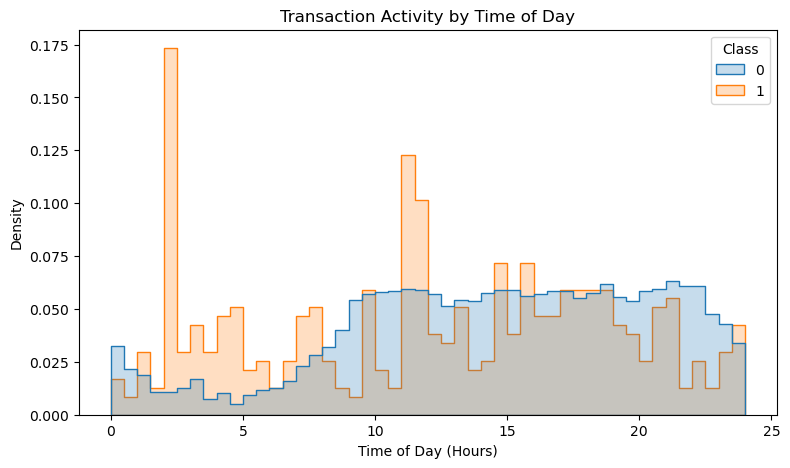

In [31]:
df["Time_Hours"] = (df["Time"] % 86400) / 3600

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="Time_Hours",
    hue="Class",
    bins=48,
    stat="density",
    common_norm=False,
    element="step"
)

plt.xlabel("Time of Day (Hours)")
plt.ylabel("Density")
plt.title("Transaction Activity by Time of Day")
plt.show()

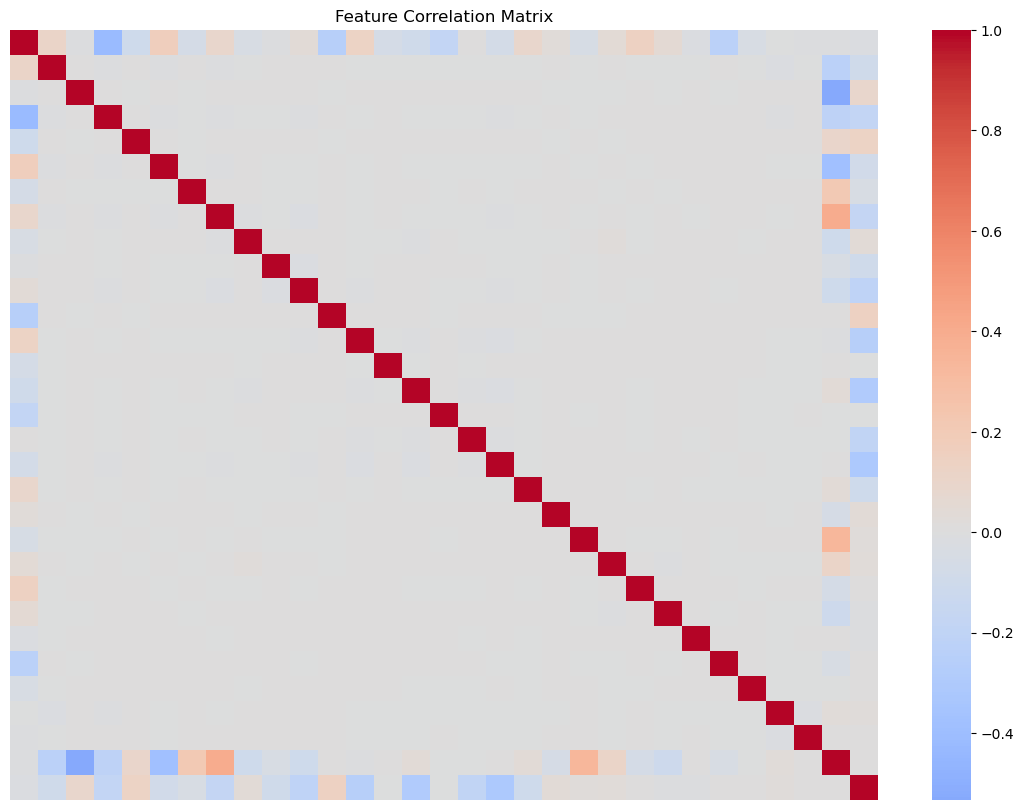

In [32]:
corr = df.drop(columns=["Amount_Log", "Time_Hours"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)

plt.title("Feature Correlation Matrix")
plt.show()


In [33]:
X = df.drop(columns=["Class", "Amount_Log", "Time_Hours"])
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)  #x : 80% for training and y : 20% for testing of model.

Features: (283726, 30)
Target: (283726,)


In [34]:
split_1 = int(len(df) * 0.70)
split_2 = int(len(df) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test = X.iloc[split_2:]
y_test = y.iloc[split_2:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nFraud rate:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean())

Train: (198608, 30) (198608,)
Validation: (42559, 30) (42559,)
Test: (42559, 30) (42559,)

Fraud rate:
Train: 0.0018428260694433255
Validation: 0.0012923235978288964
Test: 0.001221833219765502


In [35]:
print("Fraud cases:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

print("\nClass distribution:")
print(pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}))

Fraud cases:
Train: 366
Validation: 55
Test: 52

Class distribution:
          Train  Validation      Test
Class                                
0      0.998157    0.998708  0.998778
1      0.001843    0.001292  0.001222


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [38]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [39]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score
)

y_val_prob = baseline_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print(classification_report(y_val, y_val_pred, digits=4))

print("ROC-AUC :", round(roc_auc_score(y_val, y_val_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_val, y_val_prob), 4))

              precision    recall  f1-score   support

           0     0.9999    0.9773    0.9885     42504
           1     0.0502    0.9273    0.0952        55

    accuracy                         0.9772     42559
   macro avg     0.5251    0.9523    0.5419     42559
weighted avg     0.9987    0.9772    0.9873     42559

ROC-AUC : 0.9824
PR-AUC  : 0.8367


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [42]:
print("Random Forest trained:", hasattr(rf_model, "named_steps"))
print("Number of trees:", rf_model.named_steps["model"].n_estimators)

Random Forest trained: True
Number of trees: 300


In [43]:
y_rf_prob = rf_model.predict_proba(X_val)[:, 1]
y_rf_pred = (y_rf_prob >= 0.5).astype(int)

print(classification_report(y_val, y_rf_pred, digits=4))

print("ROC-AUC :", round(roc_auc_score(y_val, y_rf_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_val, y_rf_prob), 4))

              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     42504
           1     1.0000    0.6909    0.8172        55

    accuracy                         0.9996     42559
   macro avg     0.9998    0.8455    0.9085     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC : 0.9794
PR-AUC  : 0.8664


In [44]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_rf_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = f1[:-1].argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold:", round(best_threshold, 4))
print("Precision:", round(precision[best_idx], 4))
print("Recall:", round(recall[best_idx], 4))
print("F1-Score:", round(f1[best_idx], 4))

Best Threshold: 0.2567
Precision: 1.0
Recall: 0.7818
F1-Score: 0.8776


In [45]:
y_test_prob = rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred, digits=4))

print("ROC-AUC :", round(roc_auc_score(y_test, y_test_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_test_prob), 4))

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     42507
           1     0.9070    0.7500    0.8211        52

    accuracy                         0.9996     42559
   macro avg     0.9533    0.8750    0.9104     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC : 0.9372
PR-AUC  : 0.7657


In [46]:
from sklearn.metrics import accuracy_score

print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))

Accuracy : 0.9996


[[42503     4]
 [   13    39]]


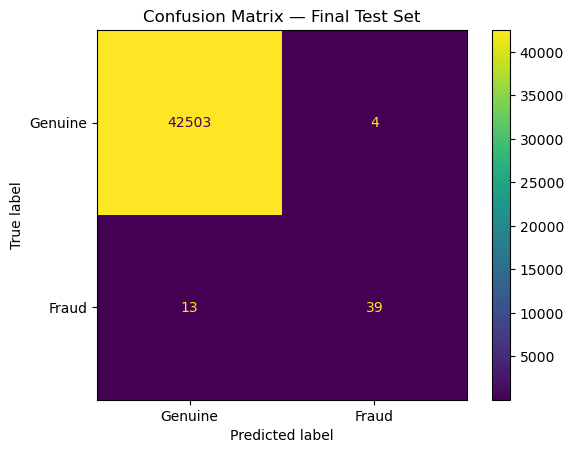

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
).plot()

plt.title("Confusion Matrix — Final Test Set")
plt.show()

In [48]:
fp = ((y_test == 0) & (y_test_pred == 1)).sum()
fn = ((y_test == 1) & (y_test_pred == 0)).sum()

print("False Positives:", fp)
print("False Negatives:", fn)
print("Total Errors:", fp + fn)

False Positives: 4
False Negatives: 13
Total Errors: 17


In [50]:
total_test = len(y_test)

print("False Positive Rate:", round(fp / total_test, 6))
print("False Negative Rate:", round(fn / total_test, 6))

False Positive Rate: 9.4e-05
False Negative Rate: 0.000305


In [51]:
fraud_total = (y_test == 1).sum()
genuine_total = (y_test == 0).sum()

print("Fraud Miss Rate (False Negative Rate):",
      round(fn / fraud_total * 100, 2), "%")

print("Genuine False Alarm Rate (False Positive Rate):",
      round(fp / genuine_total * 100, 4), "%")

Fraud Miss Rate (False Negative Rate): 25.0 %
Genuine False Alarm Rate (False Positive Rate): 0.0094 %


In [52]:
rf = rf_model.named_steps["model"]

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

V14    0.157062
V10    0.122486
V4     0.107058
V12    0.106395
V17    0.082385
V11    0.068488
V16    0.062030
V3     0.047281
V7     0.030155
V2     0.028189
V21    0.019846
V9     0.017037
V19    0.012632
V5     0.011801
V18    0.011502
dtype: float64


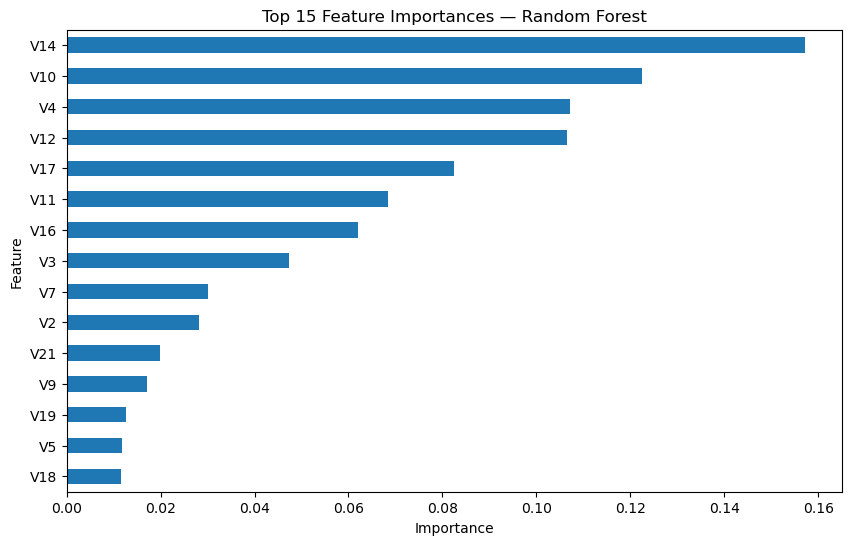

In [53]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [54]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_prob),
        roc_auc_score(y_val, y_rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_prob),
        average_precision_score(y_val, y_rf_prob)
    ]
})

print(model_comparison.round(4))

                 Model  ROC-AUC  PR-AUC
0  Logistic Regression   0.9824  0.8367
1        Random Forest   0.9794  0.8664


In [55]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is not installed.


In [56]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

hgb_model.fit(X_train, y_train)

print("HistGradientBoosting trained successfully.")

  File "C:\Users\khush\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\khush\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khush\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khush\anaconda3\Lib\subprocess.

HistGradientBoosting trained successfully.


In [57]:
print(type(hgb_model))
print("Model is ready:", hgb_model is not None)

<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
Model is ready: True


In [58]:
y_hgb_prob = hgb_model.predict_proba(X_val)[:, 1]
y_hgb_pred = (y_hgb_prob >= 0.5).astype(int)

print(classification_report(y_val, y_hgb_pred, digits=4))
print("ROC-AUC :", round(roc_auc_score(y_val, y_hgb_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_val, y_hgb_prob), 4))

              precision    recall  f1-score   support

           0     0.9998    0.9974    0.9986     42504
           1     0.2994    0.8545    0.4434        55

    accuracy                         0.9972     42559
   macro avg     0.6496    0.9260    0.7210     42559
weighted avg     0.9989    0.9972    0.9979     42559

ROC-AUC : 0.9784
PR-AUC  : 0.8418


In [60]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_val_prob),
        roc_auc_score(y_val, y_rf_prob),
        roc_auc_score(y_val, y_hgb_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_val, y_val_prob),
        average_precision_score(y_val, y_rf_prob),
        average_precision_score(y_val, y_hgb_prob)
    ]
})

print("model_comparison",model_comparison.round(4))

model_comparison                   Model  ROC-AUC  PR-AUC
0   Logistic Regression   0.9824  0.8367
1         Random Forest   0.9794  0.8664
2  HistGradientBoosting   0.9784  0.8418


In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds_to_check = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

rows = []

for t in thresholds_to_check:
    pred = (y_rf_prob >= t).astype(int)

    rows.append({
        "Threshold": t,
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)

print(threshold_df.round(4))

   Threshold  Precision  Recall      F1
0       0.10     0.9000  0.8182  0.8571
1       0.15     0.9773  0.7818  0.8687
2       0.20     0.9773  0.7818  0.8687
3       0.25     1.0000  0.7818  0.8776
4       0.30     1.0000  0.7455  0.8542
5       0.35     1.0000  0.7455  0.8542
6       0.40     1.0000  0.7273  0.8421
7       0.50     1.0000  0.6909  0.8172


In [63]:
import joblib

joblib.dump(rf_model, "fraud_detection_random_forest.pkl")

print("Model saved successfully.")

Model saved successfully.


In [64]:
import joblib

loaded_model = joblib.load("fraud_detection_random_forest.pkl")

print("Model loaded successfully.")
print(type(loaded_model))

Model loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [65]:
import joblib

fraud_artifact = {
    "model": rf_model,
    "threshold": best_threshold,
    "features": X.columns.tolist()
}

joblib.dump(fraud_artifact, "fraud_detection_artifact.pkl")

print("Production artifact saved successfully.")

Production artifact saved successfully.


In [66]:
artifact = joblib.load("fraud_detection_artifact.pkl")

print("Artifact loaded successfully.")
print("Threshold:", artifact["threshold"])
print("Number of features:", len(artifact["features"]))
print("Model type:", type(artifact["model"]))

Artifact loaded successfully.
Threshold: 0.25666666666666665
Number of features: 30
Model type: <class 'sklearn.pipeline.Pipeline'>


In [67]:
import pandas as pd
import joblib

artifact = joblib.load("fraud_detection_artifact.pkl")

sample_transaction = X_test.iloc[[0]]

probability = artifact["model"].predict_proba(sample_transaction)[0, 1]
prediction = int(probability >= artifact["threshold"])

print("Fraud Probability:", round(probability, 4))
print("Prediction:", prediction)
print("Result:", "Fraud" if prediction == 1 else "Genuine")

Fraud Probability: 0.0
Prediction: 0
Result: Genuine


In [68]:
fraud_sample = X_test.loc[y_test == 1].iloc[[0]]

probability = artifact["model"].predict_proba(fraud_sample)[0, 1]
prediction = int(probability >= artifact["threshold"])

print("Fraud Probability:", round(probability, 4))
print("Prediction:", prediction)
print("Actual Class:", y_test.loc[fraud_sample.index].iloc[0])
print("Result:", "Fraud" if prediction == 1 else "Genuine")

Fraud Probability: 0.6933
Prediction: 1
Actual Class: 1
Result: Fraud


In [69]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

y_test_prob = artifact["model"].predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= artifact["threshold"]).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_test_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Accuracy: 0.9996
ROC-AUC: 0.9372
PR-AUC: 0.7657

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42507
           1       0.91      0.75      0.82        52

    accuracy                           1.00     42559
   macro avg       0.95      0.87      0.91     42559
weighted avg       1.00      1.00      1.00     42559

Confusion Matrix:
[[42503     4]
 [   13    39]]
